<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# II. Análise de extensões. Extensometria. Equações da compatibilidade.

## Problema 6 II <a name="PII56"></a>

As componentes do deslocamento num corpo submetido a esforços no seu plano são (unidades em mm):

\begin{equation*}
	\begin{cases}
	u = 0.01x + 0.002y \\[.5ex]
	v = 0.02x + 0.002z \\[.5ex]
	w = 0.001x + 0.005
	\end{cases}
\end{equation*}

Determine a variação de comprimento da diagonal $(0, 0, 0)(1, 1,1)$, bem como a extensão linear ao longo dessa direção.

[a)](#A) Pela definição de vetor deslocamento.

[b)](#B) Pela matriz das deformações de Green ou matriz das deformações de Lagrange,

[c)](#B) Pela matriz das deformações infinitesimais.

## Resolução

#### a) Pela definição de vetor deslocamento.<a name="A"></a>

([enunciatum](#PII56))

Considere-se um sistema de coordenadas ortonormado e direto $S(0,\vec{\imath},\vec{\jmath}, \vec{k})$ arbitrariamente escolhido. A expressão cartesiana do vetor posição de um ponto $P$ do espaço onde se encontra uma partícula do sólido no instante inicial (configuração inicial) é dada por:

\begin{equation*}
\vec{r} = x \vec{\imath} + y \vec{\jmath} + z \vec{k}
\end{equation*}

Considere-se que, pela solicitação de forças externas, o sólido ocupa uma nova região no espaço num determinado instante $t$. A partícula que inicialmente estava na posição $P$ transformou-se para uma nova posição no espaço $P'$. O seu vetor posicional atual no sistema de coordenadas $S$ é dado por:

\begin{equation*}
\vec{r}{~'}(t) = x'(t) \vec{\imath} + y'(t) \vec{\jmath} + z'(t) \vec{k}
\end{equation*}

Define-se deslocamento da partícula genérica $P$, $\vec{u}(t)$, ao vetor com origem em $P$ e extremidade em $P'$. O vetor deslocamento tem a seguinte expressão cartesiana no sistema de coordenadas $S$:

\begin{equation*}
\vec{u}(t) = u(t) \vec{\imath} + v(t) \vec{\jmath} + w(t) \vec{k}
\end{equation*}

Pela adição de vetores, é possível concluir que os vetores $\vec{r}$, $\vec{r}{~'}(t) $ e $\vec{u}(t)$ estão relacionados pela seguinte expressão:

\begin{equation*}
\vec{r}{~'}(t) = \vec{r} + \vec{u}(t)
\end{equation*}

Em geral são distintos os deslocamentos sofridos pelas diferentes partículas materiais do corpo. Desta forma, o vetor deslocamento é genericamente uma função do tempo e também uma função  do ponto $P$:

\begin{equation*}
\vec{u} = \vec{u}(P,t)
\end{equation*}

Esta expressão vetorial é equivalente a três funções reais cujas equações cartesiana são dadas por:

\begin{equation*}
\begin{cases}
u = u(x,y,z,t) \\
v = v(x,y,z,t) \\
w = w(x,y,z,t)
\end{cases}
\end{equation*}

Nestas equações tomou-se como variável independente o ponto genérico $P$ (ou as suas coordenadas - $(x,y,z)$ - num dado sistema de coordenadas $S$) que a partícula ocupa na configuração inicial. Assim, as coordenadas do ponto $P'$ no instante $t$ da configuração atual podem ser obtidas  a partir das seguintes relações:

\begin{equation*}
\begin{cases}
x' = x + u(x,y,z,t) \\
y' = y + v(x,y,z,t) \\
z' = z + w(x,y,z,t)
\end{cases}
\end{equation*}

Este modo de representar o movimento de um meio contínuo é conhecido por descrição material ou de Lagrange - Joseph Louis Lagrange [1736-1813).

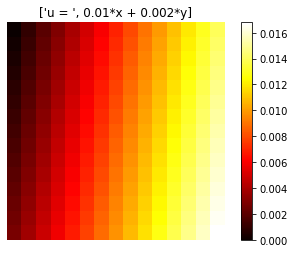

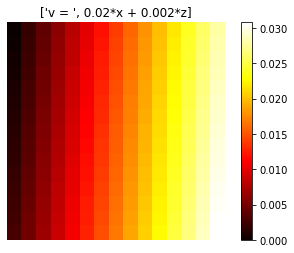

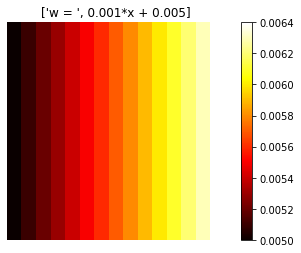

In [196]:
import numpy as np
import sympy as sy
from sympy import diff, Derivative
from sympy.solvers import solve
from sympy import symbols
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
from pylab import meshgrid,cm,imshow,contour,clabel,colorbar,axis,title,show

u, v, w, x, y, z = symbols('u v w x y z')

a100 = 0.01; a020 = 0.002
b200 = 0.02; b003 = 0.002
c100 = 0.001; c000 = 0.005

def u(x,y): return a100*x + a020*y
def v(x,z): return b200*x + b003*z
def w(x): return c100*x + c000

xQ = np.arange(0.,1.5,.1); yQ = xQ; zQ = xQ
X1,Y1 = np.meshgrid(xQ, yQ) # grid of point
X2,Z2 = np.meshgrid(xQ, zQ)
X3,Z3 = np.meshgrid(xQ,np.zeros(zQ.size))

def PlotFig(X,Y,Z,stg):
    plt.figure(111)
    colorbar(imshow(Z,cmap=cm.hot))
    title(stg), plt.axis('off')
    plt.show()

PlotFig(X1,Y1,u(X1,Y1),['u = ',u(x,y)])
PlotFig(X2,Z2,v(X2,Z2),['v = ',v(x,z)])
PlotFig(X3,Z3,w(X3),['w = ',w(x)])

A variação de comprimento da diagonal $(0, 0, 0)(1, 1,1)$ pode ser obtida pela definição do vetor deslocamento de acordo com

In [197]:
def vetPosicao(Qx,Qy,Qz): return np.array([Qx,Qy,Qz])

def analise(i):
    if i == 1:
        xP, yP, zP = 0, 0, 0
        xQ, yQ, zQ = 1, 1, 1
        return xP, yP, zP, xQ, yQ, zQ
    elif i == 2:
        xP, yP, zP = 0, 0, 0
        xQ, yQ, zQ = 0.001, 0.001, 0.001
        return xP, yP, zP, xQ, yQ, zQ
    else:
        return

coord = analise(2)

P0 = vetPosicao(coord[0], coord[1], coord[2])
Q0 = vetPosicao(coord[3], coord[4], coord[5])

print('configuração inicial (0): -----------------')
print('ponto P (0) = ',P0)
print('ponto Q (0) = ',Q0)

vecPQ0 = Q0 - P0
print('vetor PQ (0) = ',vecPQ0,' mm')
norPQ0 = np.sqrt(np.dot(vecPQ0,vecPQ0))
print('norma vecPQ (0) = ','{:.5f}'.format(norPQ0),' mm')

def Trans01(Ponto):
    x0 = Ponto[0]
    y0 = Ponto[1]
    z0 = Ponto[2]
    x1 = x0 + u(x0,y0)
    y1 = y0 + v(x0,z0)
    z1 = z0 + w(x0)
    return np.array([x1, y1, z1])

P1 = Trans01(P0)
Q1 = Trans01(Q0)

print('\nconfiguração final (1): -----------------')
print('ponto P (1) = ',P1)
print('ponto Q (1) = ',Q1)

vecPQ1 = Q1 - P1
print('vetor PQ (1) = ',vecPQ1,' mm')
norPQ1 = np.sqrt(np.dot(vecPQ1,vecPQ1))
print('norma vecPQ (1) = ','{:.5f}'.format(norPQ1),' mm')

VarComprimQ = norPQ1 - norPQ0
print('\nVariação de comprimento do segmento PQ : -----------------')
print('\n |PQ1| - |PQ0| = ','{:.7f}'.format(norPQ1),' - ','{:.7f}'.format(norPQ0),' = ','{:.7f}'.format(VarComprimQ),' mm')
print('\n eps = |PQ1| - |PQ0| / |PQ0| = ','{:.7f}'.format(VarComprimQ/norPQ0))

configuração inicial (0): -----------------
ponto P (0) =  [0 0 0]
ponto Q (0) =  [0.001 0.001 0.001]
vetor PQ (0) =  [0.001 0.001 0.001]  mm
norma vecPQ (0) =  0.00173  mm

configuração final (1): -----------------
ponto P (1) =  [0.    0.    0.005]
ponto Q (1) =  [0.001012 0.001022 0.006001]
vetor PQ (1) =  [0.001012 0.001022 0.001001]  mm
norma vecPQ (1) =  0.00175  mm

Variação de comprimento do segmento PQ : -----------------

 |PQ1| - |PQ0| =  0.0017523  -  0.0017321  =  0.0000203  mm

 eps = |PQ1| - |PQ0| / |PQ0| =  0.0117030


#### b) Pela matriz das deformações de Green ou matriz das deformações de Lagrange.<a name="B"></a>

([enunciatum](#PII56))

Em certos problemas, como é o caso da estática dos corpos elásticos, a descrição do movimento de um corpo é apenas função da sua posição inicial e posição final, sendo independente do caminho entre estas. Nestas condições o campo de deslocmentos pode ser considerado apenas uma função das coordenadas do ponto $P$ da configuração de referência (descrição de Lagrange):

\begin{equation*}
\vec{u} = \vec{u}(P), \quad P \in R
\end{equation*}

Uma forma possível de escrever esta função vetorial, que fatisfaz os requisitos de continuidade e de univocidade é considerar as componentes do vetor deslocamento duma partícula ($u, v, w$) funções lineares das coordenadas iniciais dessa partícula ($x, y, z$) num dado sistema de coordendas $S(0,\vec{\imath},\vec{\jmath},\vec{k})$:

\begin{equation*}
\begin{cases}
u = u_0 + a_{11} x + a_{12} y + a_{13} z\\
v = v_0 + a_{21} x + a_{22} y + a_{23} z\\
w = w_0 + a_{31} x + a_{32} y + a_{33} z
\end{cases}
\end{equation*}

em que $u_0, v_0, w_0$ e $a_{ij} (i,j=1,2,3)$ são constantes. De forma matricial compacta a equação anterior escreve-se:

\begin{equation*}
\vec{u} = \vec{u}_0 + [A] \vec{r}
\end{equation*}

ou ainda

\begin{equation*}
\vec{r}' = \vec{r} + \vec{u}_0 + [A] \vec{r}
\end{equation*}

A partir desta relação é possível obter a relação entre os deslocamentos de dois pontos arbitrários $P$ e $Q$. Para o efeito, considere-se:

\begin{equation*}
\begin{cases}
\vec{u}(P) &= \vec{u}_0 + [A] \vec{r}(P) \\[.5ex]
\vec{u}(Q) &= \vec{u}_0 + [A] \vec{r}(Q) \\
\end{cases}
\end{equation*}

Uma vez que:

\begin{equation*}
\begin{aligned}
\vec{r}(Q) &= \vec{r}(P) + \vec{PQ} \\
[A]\vec{r}(Q) &= [A]\vec{r}(P) + [A]\vec{PQ}\\
\vec{u}(Q) - \vec{u}_0 &= \vec{u}(P) - \vec{u}_0 + [A]\vec{PQ}\\
\end{aligned}
\end{equation*}

Pelo que,

\begin{equation*}
\vec{u}(Q) = \vec{u}(P) + [A]\vec{PQ}\\
\end{equation*}

Seja $\vec{V}$ o segmento de reta orientado entre os pontos $P$ e $Q$: $\vec{V} = \vec{PQ}$. Assumindo uma transformação afim homogénea entre a configuração de referência e a configuração atual, então o vetor $\vec{V}$ transforma-se noutro segmento de reta orientado $\vec{V}{~'}$ tal que:  $\vec{V}{~'} = \vec{P'Q'}$. Designe-se por $\delta\vec{V}$ o vetor que é a diferença entre $\vec{V}{~'}$ e $\vec{V}$. Então é possível mostrar que:

\begin{equation*}
\delta\vec{V} = \vec{V}{~'} - \vec{V} = \vec{u}(Q) - \vec{u}(P) = [A]\vec{V}\\
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au05/Au05_P006_i1.jpg"
width="300" height="200">

Pelo que a matriz $[A]$ da transformação afim local de $\mathrm{R}$ em $\mathrm{R}'$ determina completamente a variação das componentes dum segmento de reta orientado infinitesimal.

Por outro lado a relação entre os deslocamentos $\vec{u}(Q)$ e $\vec{u}(P)$ pode ser obtida por expansão em série de McLaurin da função $\vec{u}(P)$ na vizinhança de $P$, em primeira aproximação definida por:

\begin{equation*}
\vec{u}(Q) = \vec{u}(P) + \left.\frac{\partial \vec{u}}{\partial x}\right|_P \mathrm{d}x +
\left.\frac{\partial \vec{u}}{\partial y}\right|_P \mathrm{d}y +
\left.\frac{\partial \vec{u}}{\partial z}\right|_P \mathrm{d}z
\end{equation*}

Na forma matricial a equação vetorial anterior tem a forma:

\begin{equation*}
\begin{bmatrix}
u(Q) - u(P) \\
v(Q) - v(P)  \\
w(Q) - w(P)
\end{bmatrix} =
\begin{bmatrix}
\left.\displaystyle\frac{\partial u}{\partial x}\right|_P \\
\left.\displaystyle\frac{\partial v}{\partial x}\right|_P \\
\left.\displaystyle\frac{\partial w}{\partial x}\right|_P
\end{bmatrix} \mathrm{d}x +
\begin{bmatrix}
\left.\displaystyle\frac{\partial u}{\partial y}\right|_P \\
\left.\displaystyle\frac{\partial v}{\partial y}\right|_P \\
\left.\displaystyle\frac{\partial w}{\partial y}\right|_P
\end{bmatrix} \mathrm{d}y +
\begin{bmatrix}
\left.\displaystyle\frac{\partial u}{\partial z}\right|_P \\
\left.\displaystyle\frac{\partial v}{\partial z}\right|_P \\
\left.\displaystyle\frac{\partial w}{\partial z}\right|_P
\end{bmatrix}
\mathrm{d}z
\end{equation*}

Desta forma se mostra que $[A]$, conhedica por matriz do gradiente de deslocamentos vem assim definida:

\begin{equation*}
[A] \equiv \mathrm{grad} \vec{u} \equiv \vec{\nabla} \vec{u} = \begin{bmatrix}
a_{11} & a_{12} & a_{13} \\
a_{21} & a_{22} & a_{23} \\
a_{31} & a_{32} & a_{33}
\end{bmatrix} =
\begin{bmatrix}
\displaystyle\left(\frac{\partial u}{\partial x}\right)_P &
\displaystyle\left(\frac{\partial u}{\partial y}\right)_P &
\displaystyle\left(\frac{\partial u}{\partial z}\right)_P \\
\displaystyle\left(\frac{\partial v}{\partial x}\right)_P &
\displaystyle\left(\frac{\partial v}{\partial y}\right)_P &
\displaystyle\left(\frac{\partial v}{\partial z}\right)_P \\
\displaystyle\left(\frac{\partial w}{\partial x}\right)_P &
\displaystyle\left(\frac{\partial w}{\partial y}\right)_P &
\displaystyle\left(\frac{\partial w}{\partial z}\right)_P
\end{bmatrix}
\end{equation*}

Normalizando a expressão anterior: $\delta\vec{V} = [A]\vec{V}$ pelo comprimento inicial da fibra $\vec{PQ}$ resulta:

\begin{equation*}
\begin{aligned}
\frac{\delta\vec{V}}{V} = [A]\frac{\vec{V}}{V}\\
\vec{A} = [A]\vec{n}\\
\end{aligned}
\end{equation*}

Esta equação expressa uma aplicação linear que a cada versor $\vec{n}$ faz corresponder um vetor $\vec{A}$ que representa a variação relativa de um vetor elementar $\vec{V}$ que tem origem no ponto genérico $P$ da configuração inicial dum meio material contínuo e que tem a direção e o sentido do versos $\vec{n}$. Como a matriz do gradiente de deslocamentos varia tipicamente de ponto para ponto, então $\vec{A}$ é não só função de $\vec{n}$ mas também de $P$: $\vec{A} = \vec{A}(P,\vec{n})$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au05/Au05_P006_i2.jpg"
width="300" height="200">

Seja $\vec{V}$ o vetor definido por dois pontos $P$ e $Q$ ($\vec{PQ}$) de uma região elementar $\mathrm{d}R$ (configuração de referência) e seja $\vec{V}{~'}$ o seu transformado na região $\mathrm{d}R{~'}$ (configuração deformada).

Define-se deformação linear à seguinte grandeza que expressa a variação entre as normas destes vetores:

\begin{equation*}
\varepsilon = \frac{V{~'}-V}{V}
\end{equation*}

Ocorrendo deformação do corpo, haverá uma variação entre os vetores $\vec{V}$ e $\vec{V}{~'}$, potencialmente quer de comprimento quer de orientação, tal que:

\begin{equation*}
\vec{V}{~'} = \vec{V} + \delta\vec{V}
\end{equation*}

As normas dos vetores  $\vec{V}$ e $\vec{V}{~'}$ podem ainda ser relacionadas considerando o desenvolvimento algébrico do produto interno (ou escalar) de $\vec{V}{~'}$ por si próprio:

\begin{equation*}
\begin{aligned}
\vec{V}{~'} \cdot \vec{V}{~'} &= (\vec{V} + \delta\vec{V}) \cdot (\vec{V} + \delta\vec{V}) \\
V{~'}^2 &= V^2 + 2 \vec{V} \cdot \delta\vec{V} + \delta\vec{V} \cdot \delta\vec{V} \\
\frac{1}{2}\left( \frac{V{~'}^2-V^2}{V^2} \right)&= \frac{\vec{V}}{V} \cdot \frac{\delta\vec{V}}{V} +
\frac{1}{2} \frac{\delta\vec{V}}{V} \cdot \frac{\delta\vec{V}}{V} \\
\end{aligned}
\end{equation*}

A grandeza adimensional que figura no primeiro membro da última equação é conhecida por deformação de Lagrange:

\begin{equation*}
E = \frac{1}{2}\left( \frac{V{~'}^2-V^2}{V^2} \right)
\end{equation*}

A deformação de Lagrange, $E$, pode ser reescrita na forma:

\begin{equation*}
E = \vec{n}^\mathrm{T} [A] \vec{n} + \frac{1}{2}\vec{n}^\mathrm{T} [A]^\mathrm{T}[A] \vec{n}
\end{equation*}

Notando que,

\begin{equation*}
\vec{n}^\mathrm{T} [A] \vec{n} = \vec{n}^\mathrm{T} \frac{[A]+[A]^\mathrm{T}}{2} \vec{n}
\end{equation*}

A expressão para a deformação de Lagrange vem

\begin{equation*}
E = \vec{n}^\mathrm{T} [E] \vec{n}
\end{equation*}

onde,

\begin{equation*}
[E] = \frac{1}{2}[A] + \frac{1}{2}[A]^\mathrm{T} + \frac{1}{2}[A]^\mathrm{T}[A]
\end{equation*}

A matriz $[E]$ é conhecida por matriz das deformações de Green ou matriz das deformações de Lagrange. Como as matrizes $[A] + [A]^\mathrm{T}$ e $[A]^\mathrm{T}[A]$ são simétricas  também $[E]$ é simétrica, podendo ser representada por

\begin{equation*}
[E] =
\begin{bmatrix}
E_{xx} & G_{xy} & G_{xz} \\
G_{xy} & E_{yy} & G_{yz} \\
G_{xz} & G_{yz} & E_{zz}
\end{bmatrix}
\end{equation*}

Os elementos desta matriz podem ser expressos diretamente à custa dos elementos da matriz $[A]$:

\begin{equation*}
\begin{aligned}
E_{xx} & = \frac{\partial u}{\partial x} + \frac{1}{2}\left[ \left(\frac{\partial u}{\partial x}\right)^2 +
\left(\frac{\partial v}{\partial x}\right)^2 + \left(\frac{\partial w}{\partial x}\right)^2\right]\\
E_{yy} & = \frac{\partial u}{\partial x} + \frac{1}{2}\left[ \left(\frac{\partial u}{\partial y}\right)^2 +
\left(\frac{\partial v}{\partial y}\right)^2 + \left(\frac{\partial w}{\partial y}\right)^2\right] \\
E_{zz} & = \frac{\partial u}{\partial x} + \frac{1}{2}\left[ \left(\frac{\partial u}{\partial z}\right)^2 +
\left(\frac{\partial v}{\partial z}\right)^2 + \left(\frac{\partial w}{\partial z}\right)^2\right]\\
G_{xy} & = \frac{1}{2}\left(\frac{\partial u}{\partial y} + \frac{\partial v}{\partial x}\right) +
\frac{1}{2} \left( \frac{\partial u}{\partial x}\frac{\partial u}{\partial y} +
\frac{\partial v}{\partial x}\frac{\partial v}{\partial y} +
\frac{\partial w}{\partial x}\frac{\partial w}{\partial y} \right) \\
G_{xz} & = \frac{1}{2}\left(\frac{\partial u}{\partial z}+\frac{\partial w}{\partial x}\right) +
\frac{1}{2} \left( \frac{\partial u}{\partial x}\frac{\partial u}{\partial z} +
\frac{\partial v}{\partial x}\frac{\partial v}{\partial z} +
\frac{\partial w}{\partial x}\frac{\partial w}{\partial z} \right)\\
G_{yz} & = \frac{1}{2}\left(\frac{\partial v}{\partial z}+\frac{\partial w}{\partial y}\right) +
\frac{1}{2} \left( \frac{\partial u}{\partial y}\frac{\partial u}{\partial z} +
\frac{\partial v}{\partial y}\frac{\partial v}{\partial z} +
\frac{\partial w}{\partial y}\frac{\partial w}{\partial z} \right)\\
\end{aligned}
\end{equation*}

In [200]:
u1 = u(x,y)
v1 = v(x,z)
w1 = w(x)

# componentes cartesianas da matriz das deformações de Green-Lagrange
Exx = diff(u1, x) + 0.5*(diff(u1, x)**2 + diff(v1, x)**2 + diff(w1, x)**2)
print('\nExx :',Exx)
Eyy = diff(v1, y) + 0.5*(diff(u1, y)**2 + diff(v1, y)**2 + diff(w1, y)**2)
print('Eyy :',Eyy)
Ezz = diff(w1, z) + 0.5*(diff(u1, z)**2 + diff(v1, z)**2 + diff(w1, z)**2)
print('Ezz :',Ezz)
Gxy = 0.5*(diff(u1, y) + diff(v1, x)) + 0.5*(diff(u1,x)*diff(u1,y) + diff(v1,x)*diff(v1,y) + diff(w1,x)*diff(w1,y))
print('Gxy :',Gxy)
Gxz = 0.5*(diff(u1, z) + diff(w1, x)) + 0.5*(diff(u1,x)*diff(u1,z) + diff(v1,x)*diff(v1,z) + diff(w1,x)*diff(w1,z))
print('Gxz :',Gxz)
Gyz = 0.5*(diff(v1, z) + diff(w1, y)) + 0.5*(diff(u1,y)*diff(u1,z) + diff(v1,y)*diff(v1,z) + diff(w1,y)*diff(w1,z))
print('Gyz :',Gyz)

print('\nMatriz das deformações, [E] :')
def mE(Exx,Gxy,Gxz,Eyy,Gyz,Ezz):
    return np.array([[Exx,Gxy,Gxz],[Gxy,Eyy,Gyz],[Gxz,Gyz,Ezz]])

mE0 = mE(Exx,Gxy,Gxz,Eyy,Gyz,Ezz)
print('\n[E] = \n',mE0)

Exx = Exx.subs({x:coord[3],y:coord[4],z:coord[5]})
Eyy = Eyy.subs({x:coord[3],y:coord[4],z:coord[5]})
Ezz = Ezz.subs({x:coord[3],y:coord[4],z:coord[5]})
Gxy = Gxy.subs({x:coord[3],y:coord[4],z:coord[5]})
Gxz = Gxz.subs({x:coord[3],y:coord[4],z:coord[5]})
Gyz = Gyz.subs({x:coord[3],y:coord[4],z:coord[5]})

mEP = mE(Exx,Gxy,Gxz,Eyy,Gyz,Ezz)
print('\n[E(Q)] = \n',mEP)


Exx : 0.0102505000000000
Eyy : 2.00000000000000e-6
Ezz : 2.00000000000000e-6
Gxy : 0.0110100000000000
Gxz : 0.000520000000000000
Gyz : 0.00100000000000000

Matriz das deformações, [E] :

[E] = 
 [[0.0102505000000000 0.0110100000000000 0.000520000000000000]
 [0.0110100000000000 2.00000000000000e-6 0.00100000000000000]
 [0.000520000000000000 0.00100000000000000 2.00000000000000e-6]]

[E(Q)] = 
 [[0.0102505000000000 0.0110100000000000 0.000520000000000000]
 [0.0110100000000000 2.00000000000000e-6 0.00100000000000000]
 [0.000520000000000000 0.00100000000000000 2.00000000000000e-6]]


Conhecida a matriz das deformações de Lagrange $[E]$, pode-se obter a extensão linear numa determinada direção através
da expressão:

\begin{equation*}
E = \underline{n}^\mathrm{T}\underline{\underline{E}}\,\underline{n} = n_i E_{ij} n_j
\end{equation*}

In [201]:
def vetor(l,m,n): return np.array([l,m,n])

vetorN = vetor(coord[3],coord[4],coord[5])
nPQ = vetorN/np.sqrt(np.dot(vetorN,vetorN))
print('nPQ =', nPQ)

epsPQE = np.dot(nPQ,np.dot(mEP,nPQ))
print('epsPQE(Q) = ', '{:.7f}'.format(epsPQE))

nPQ = [0.57735027 0.57735027 0.57735027]
epsPQE(Q) =  0.0117715


Representando por $l, m, n$ as componentes do versor $\vec{n}$ no sitema de coordenadas
$S(0,\vec{\imath},\vec{\jmath},\vec{k})$:

\begin{equation*}
\vec{n} \equiv n_i \equiv \underline{n} =
\begin{bmatrix}
l \\ m \\ n
\end{bmatrix}
\end{equation*}

Pelo que da expressão: $E = \underline{n}^\mathrm{T}\underline{\underline{E}}\,\underline{n}$, resulta a seguinte
expressão para a deformação de Lagrange:

\begin{equation*}
E = E_{xx}l^2 + E_{yy}m^2 + E_{zz}n^2 + 2G_{xy}lm + 2G_{yz}mn + 2G_{xz}ln
\end{equation*}

In [202]:
l = nPQ[0]
m = nPQ[1]
n = nPQ[2]

Elag = Exx*l**2 + Eyy*m**2 + Ezz*n**2 + 2*Gxy*l*m + 2*Gyz*m*n + 2*Gxz*l*n
print('E,Lagrange (Q) = ','{:.7f}'.format(Elag))

E,Lagrange (Q) =  0.0117715


> c) Pela matriz das deformações infinitesimais.<a name="C"></a>

([enunciatum](#PII56))

Componentes do tensor das deformações infinitésimais:

\begin{equation*}
\varepsilon_{ij} = \frac{1}{2}\left( \frac{\partial u_i}{\partial x_j}
+ \frac{\partial u_j}{\partial x_i} \right)
\end{equation*}

Explicitamente:

\begin{equation*}
\begin{aligned}
\varepsilon_{xx} &= \frac{\partial u}{\partial x} \\
\varepsilon_{yy} &= \frac{\partial v}{\partial y} \\
\varepsilon_{zz} &= \frac{\partial w}{\partial z} \\
\varepsilon_{xy} &= \frac{1}{2}\left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right)  = \frac{1}{2}\gamma_{xy}\\
\varepsilon_{yz} &= \frac{1}{2}\left( \frac{\partial v}{\partial z} + \frac{\partial w}{\partial y} \right)  = \frac{1}{2} \gamma_{yz}\\
\varepsilon_{xz} &= \frac{1}{2}\left( \frac{\partial u}{\partial z} + \frac{\partial w}{\partial x} \right) = \frac{1}{2} \gamma_{xz}\\
\end{aligned}
\end{equation*}

In [203]:
# componentes cartesianas da matriz das deformações
exx = diff(u1, x)
print('\nexx = du/dx :',exx)
eyy = diff(v1, y)
print('eyy = dv/dy :',eyy)
ezz = diff(w1, z)
print('ezz = dw/dz :',ezz)
exy  = 0.5*(diff(u1, y) + diff(v1, x) )
print('exy = 1/2 gxy = 1/2 (du/dy + dv/dx )  :',exy)
exz  = 0.5*(diff(u1, z) + diff(w1, x) )
print('exz = 1/2 gxz = 1/2 (du/dz + dw/dx )  :',exz)
eyz  = 0.5*(diff(v1, z) + diff(w1, y) )
print('eyz = 1/2 gxy = 1/2 (dv/dz + dw/dy )  :',eyz)

print('\nMatriz das deformações, [D] :')
def mD(exx,exy,exz,eyy,eyz,ezz):
    return np.array([[exx,exy,exz],[exy,eyy,eyz],[exz,eyz,ezz]])

mD0 = mD(exx,exy,exz,eyy,eyz,ezz)
print('[D(Q)] =\n',mD0)


exx = du/dx : 0.0100000000000000
eyy = dv/dy : 0
ezz = dw/dz : 0
exy = 1/2 gxy = 1/2 (du/dy + dv/dx )  : 0.0110000000000000
exz = 1/2 gxz = 1/2 (du/dz + dw/dx )  : 0.000500000000000000
eyz = 1/2 gxy = 1/2 (dv/dz + dw/dy )  : 0.00100000000000000

Matriz das deformações, [D] :
[D(Q)] =
 [[0.0100000000000000 0.0110000000000000 0.000500000000000000]
 [0.0110000000000000 0 0.00100000000000000]
 [0.000500000000000000 0.00100000000000000 0]]


A matriz das deformações vem dada por:

\begin{equation*}
\begin{aligned}
\underline{\underline{\varepsilon}} \equiv [\varepsilon] \equiv \varepsilon_{ij} &=
\begin{bmatrix}
\varepsilon_{xx} & \displaystyle\frac{1}{2}\gamma_{xy} & \displaystyle\frac{1}{2}\gamma_{xz} \\
\displaystyle\frac{1}{2}\gamma_{yx} & \varepsilon_{yy} &  \displaystyle\frac{1}{2}\gamma_{yz} \\
\displaystyle\frac{1}{2}\gamma_{zx} & \displaystyle\frac{1}{2}\gamma_{zy} & \varepsilon_{zz} \\
\end{bmatrix} \\
&=\begin{bmatrix}
0.01 & 0.02x + 0.002y & 0.0005 \\
0.02x + 0.002y & 0 &  0.003z^2 \\
0.0005 & 0.003z^2 & 0 \\
\end{bmatrix}
\end{aligned}
\end{equation*}

Para o ponto material Q(1,1,1) resulta:

In [204]:
exx = exx.subs({x:coord[3],y:coord[4],z:coord[5]})
eyy = eyy.subs({x:coord[3],y:coord[4],z:coord[5]})
ezz = ezz.subs({x:coord[3],y:coord[4],z:coord[5]})
exy = exy.subs({x:coord[3],y:coord[4],z:coord[5]})
exz = exz.subs({x:coord[3],y:coord[4],z:coord[5]})
eyz = eyz.subs({x:coord[3],y:coord[4],z:coord[5]})

mDP = mD(exx,exy,exz,eyy,eyz,ezz)
print('[D(P)] = \n',mDP)

[D(P)] = 
 [[0.0100000000000000 0.0110000000000000 0.000500000000000000]
 [0.0110000000000000 0 0.00100000000000000]
 [0.000500000000000000 0.00100000000000000 0]]


A extensão na direção definida pelo versor $\vec{n}$ vem:

\begin{equation*}
\varepsilon^{(\vec{n})} = \vec{n}\underline{\underline{D}}\vec{n} = n_i  D_{ij} n_j
\end{equation*}

O segmento de reta que une o ponto $P(0,0,0)$ ao o ponto $Q(1,1,1)$ é o vetor $\vec{PQ}=Q-P = (1,1,1)$. O versor que define a direção de $\vec{PQ}$ é:

\begin{equation*}
\vec{n} = \frac{\vec{PQ}}{||\vec{PQ}||} \, ;\quad \underline{n}^\mathrm{T}= \frac{1}{\sqrt{3}}
\begin{bmatrix}
1 & 1 & 1
\end{bmatrix}
\end{equation*}

Pelo que,

\begin{equation*}
\begin{aligned}
\varepsilon^{(\vec{n})} &= \underline{n}^\mathrm{T}[D]\underline{n} \\
& =\begin{bmatrix}
1 & 1 & 1
\end{bmatrix}
\begin{bmatrix}
0.01 & 0.022 & 0.0005 \\
0.022 & 0 &  0.003 \\
0.0005 & 0.003 & 0 \\
\end{bmatrix}
\begin{bmatrix}
1 \\ 1 \\ 1
\end{bmatrix}\left(\frac{1}{3}\right)
\end{aligned}
\end{equation*}

In [205]:
epsPQ = np.dot(nPQ,np.dot(mDP,nPQ))
print('epsPQ = ', '{:.7f}'.format(epsPQ))

print('\ndesvio pelo cálculo baseado nas matrizes [E] e [D]: ------------------')
print('{:.3f}'.format(abs(epsPQ-epsPQE)/epsPQE*100),' %')

epsPQ =  0.0116667

desvio pelo cálculo baseado nas matrizes [E] e [D]: ------------------
0.891  %


Considerando as definições de deformação linear $\varepsilon$ e deformação de Lagrange:

\begin{equation*}
V{~'} = V(1+\varepsilon) \quad\mapsto\quad E = \frac{1}{2}\left( \frac{V{~'}^2-V^2}{V^2} \right)
\end{equation*}

In [206]:
V1, V0, elin, Efin = symbols('V1 V0 e E')

def V1(): return V0*(1+elin)
def EquatEfin(v0,v1): return 0.5*(v1**2-v0**2)/v0**2

relat_elin_Efin = EquatEfin(V0,V1())
print(sy.expand(sy.simplify(relat_elin_Efin)))

0.5*e**2 + 1.0*e


Desta forma $\varepsilon$ e $E$ estão relacionadas por:

\begin{equation*}
E = \varepsilon + \frac{1}{2}\varepsilon^2
\end{equation*}

Pelo que a deformação linear $\varepsilon$ pode ser obtida a partir da deformação de Lagrange, $E$ pela seguinte expressão:

\begin{equation*}
\varepsilon = -1 \pm \sqrt{1+2E}
\end{equation*}

Verifica-se que a deformação de Lagrange $E$ deve satisfazer a inequação: $E> - 1/2$. Portanto,
conclui-se ainda que $\varepsilon > -1$, pelo que

\begin{equation*}
\varepsilon = -1 + \sqrt{1+2E}
\end{equation*}


In [207]:
epsilon = -1 + np.sqrt(1+2*float(epsPQE))
print('esps  = -1 + sqrt(1+2E) = ','{:.7f}'.format(epsilon))

print('\ndesvio pelo cálculo baseado nas matrizes [E] e [D]: ------------------')
print('{:.3f}'.format(abs(epsilon-epsPQE)/epsPQE*100),' %')

esps  = -1 + sqrt(1+2E) =  0.0117030

desvio pelo cálculo baseado nas matrizes [E] e [D]: ------------------
0.582  %


#### Em resumo

- Para o vetor inicial $(0, 0, 0)(1, 1,1)$:

\begin{equation*}
\begin{array}{rcl}
\vec{r}{~'}(t) = \vec{r} + \vec{u}(t) & : & \Delta L = 0.0202702~\textrm{mm} \\
& : & \varepsilon \equiv \Delta L/L = 0.0117030 \\
L_{ij} \equiv [E] = \displaystyle\frac{1}{2}\left(\frac{\partial u_i}{\partial x_j} +
\frac{\partial u_j}{\partial x_i} +
\frac{\partial u_k}{\partial x_i}\frac{\partial u_k}{\partial x_j}\right)
& : & \varepsilon = 0.0117715 \\
\varepsilon_{ij} = \displaystyle\frac{1}{2}\left(\frac{\partial u_i}{\partial x_j} +
\frac{\partial u_j}{\partial x_i}
\right) & : & \varepsilon = 0.0116667 \\
\varepsilon = -1 + \sqrt{1+2E} & : & \varepsilon = 0.0117030
\end{array}
\end{equation*}

- Se se considerar um pequeno segmento, e.g., $(0, 0, 0)(0.001, 0.001, 0.001)$

\begin{equation*}
\begin{array}{rcl}
\vec{r}{~'}(t) = \vec{r} + \vec{u}(t) & : & \Delta L = 0.0000203~\textrm{mm} \\
& : & \varepsilon \equiv \Delta L/L = 0.0117030 \\
L_{ij} \equiv [E] = \displaystyle\frac{1}{2}\left(\frac{\partial u_i}{\partial x_j} +
\frac{\partial u_j}{\partial x_i} +
\frac{\partial u_k}{\partial x_i}\frac{\partial u_k}{\partial x_j}\right)
& : & \varepsilon = 0.0117715 \\
\varepsilon_{ij} = \displaystyle\frac{1}{2}\left(\frac{\partial u_i}{\partial x_j} +
\frac{\partial u_j}{\partial x_i}
\right) & : & \varepsilon = 0.0116667 \\
\varepsilon = -1 + \sqrt{1+2E} & : & \varepsilon = 0.0117030
\end{array}
\end{equation*}

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>

